In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from nested_pandas import read_parquet

In [7]:
nf = read_parquet('out_mjd/mjd_61151_61152.parquet')
print(f'{len(nf)} objects')
nf.head()

12 objects


ra       dec  \
rootid                                                       
00df1ffd-5b61-4f70-a637-48e9e3c4baa5  149.643372  3.045931   
1ad5f49d-a70b-4b77-bd93-d1638f15ee05  151.583583  1.180768   
2427ed78-662c-4187-9bbc-630b4dea003c  149.386596  1.003157   
2ebfd86b-e849-44fc-bd70-b58066614aac   149.75346  2.502416   
30bdd4f6-9088-4946-8c94-3cad5c40dff7   150.33773  3.438826   

                                               diaobjectid  \
rootid                                                       
00df1ffd-5b61-4f70-a637-48e9e3c4baa5  [170296773073960990]   
1ad5f49d-a70b-4b77-bd93-d1638f15ee05  [170296773142642840]   
2427ed78-662c-4187-9bbc-630b4dea003c  [170296772285956137]   
2ebfd86b-e849-44fc-bd70-b58066614aac  [170296772029055002]   
30bdd4f6-9088-4946-8c94-3cad5c40dff7  [170296772055269400]   

                                                                             lightcurve  
rootid                                                                                   
00df1ffd-5b61-4f70-a637-48e9e3c4baa5  [{diaforcedsourceid: NaN, diasourceid: 1702967...  
1ad5f49d-a70b-4b77-bd93-d1638f15ee05  [{diaforcedsourceid: NaN, diasourceid: 1702967...  
2427ed78-662c-4187-9bbc-630b4dea003c  [{diaforcedsourceid: NaN, diasourceid: 1702967...  
2ebfd86b-e849-44fc-bd70-b58066614aac  [{diaforcedsourceid: NaN, diasourceid: 1702967...  
30bdd4f6-9088-4946-8c94-3cad5c40dff7  [{diaforcedsourceid: NaN, diasourceid: 1702967...

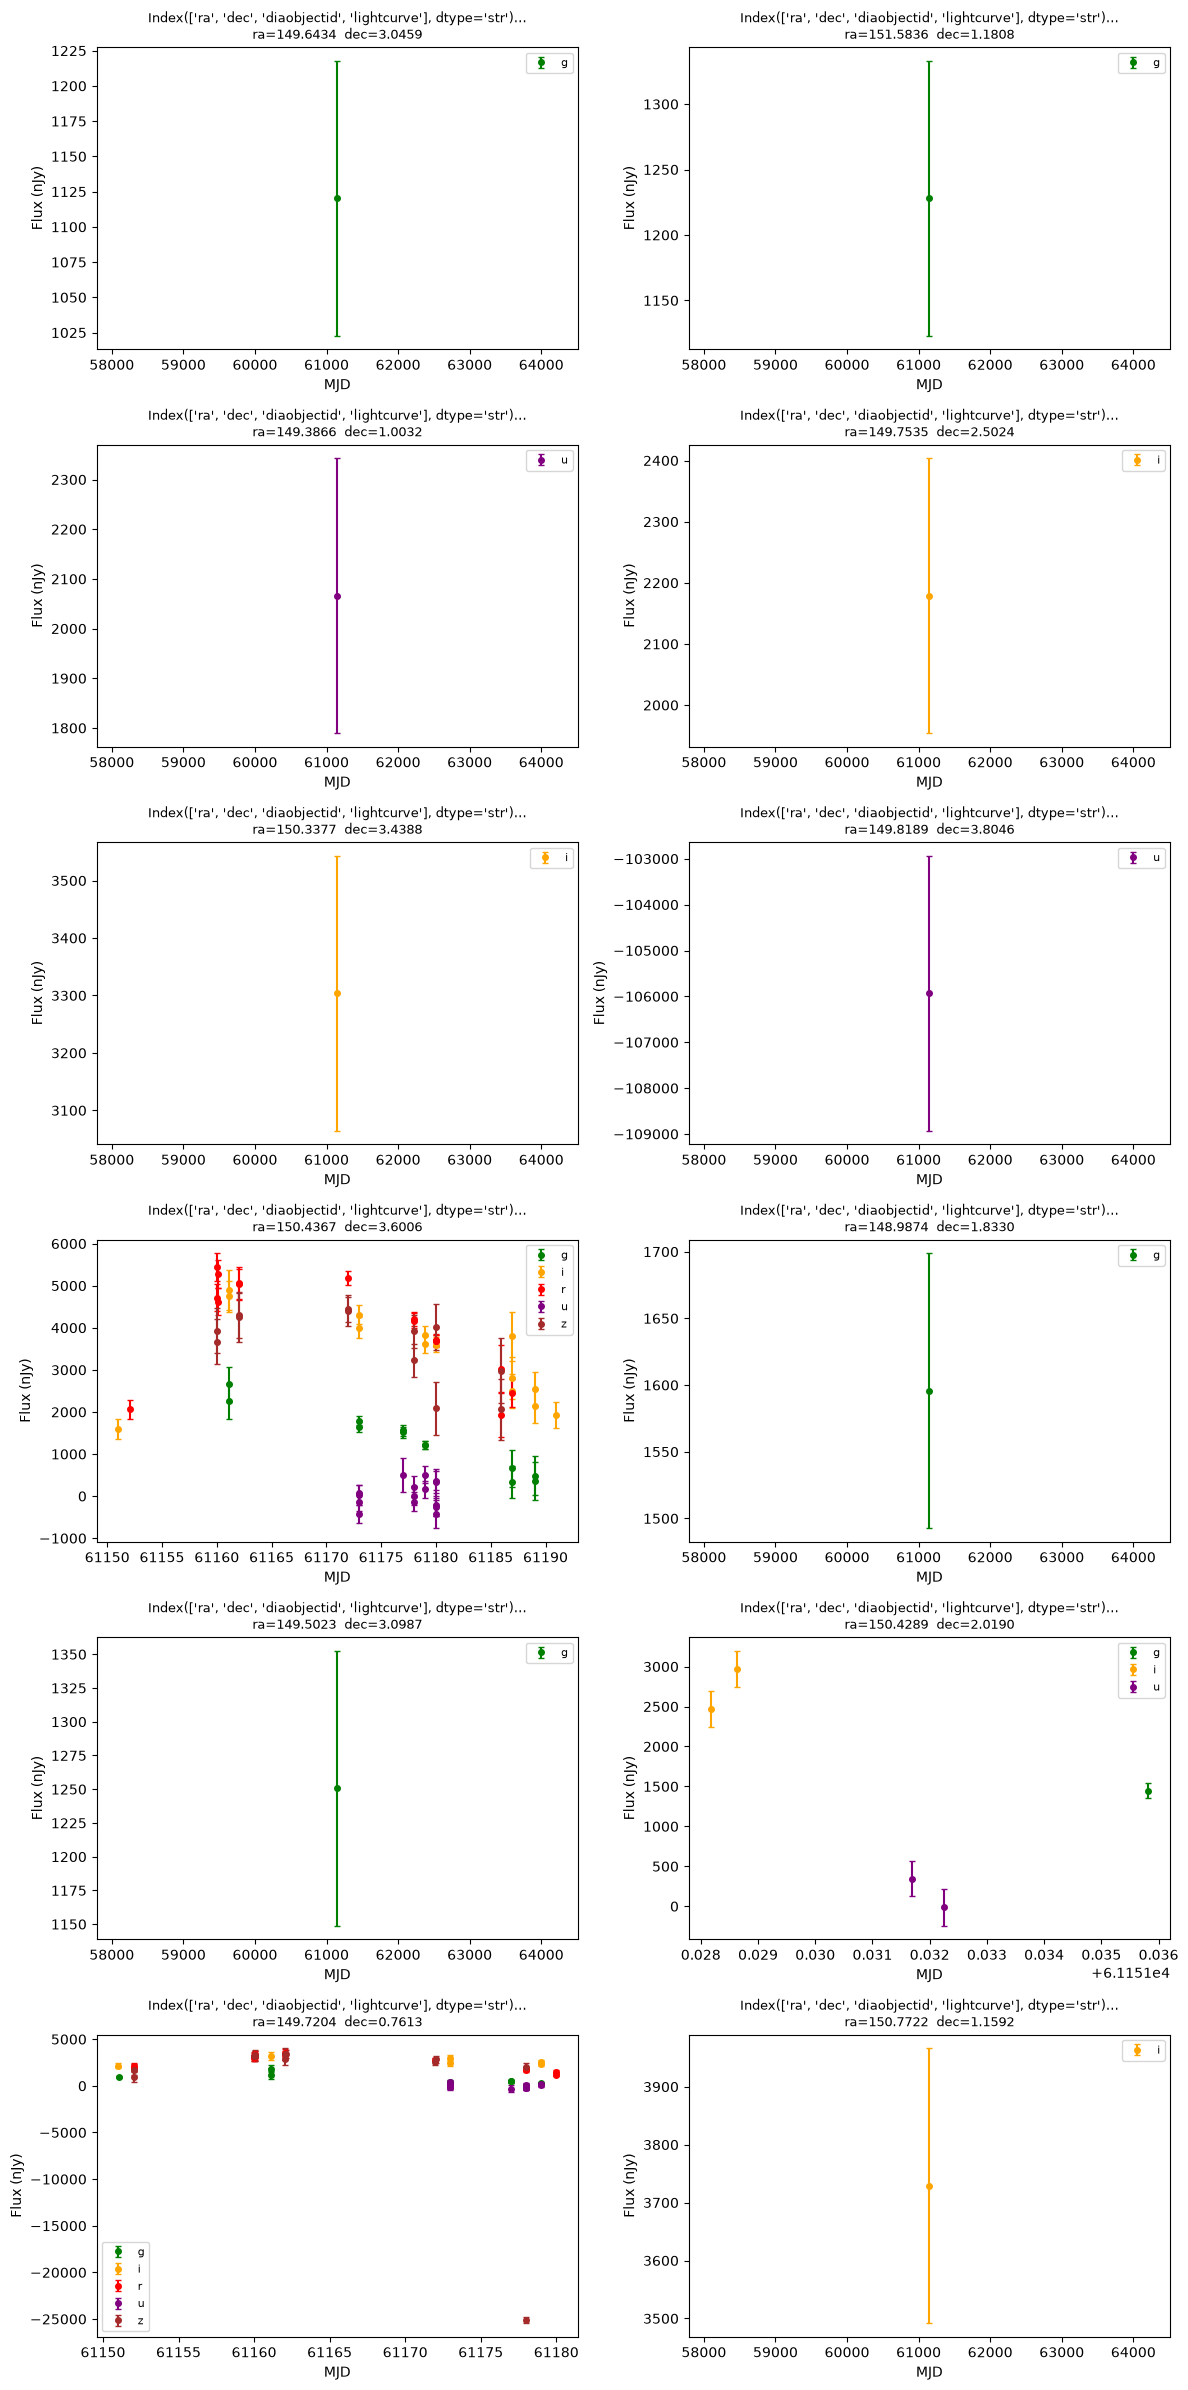

In [8]:
BAND_COLORS = {'u': 'purple', 'g': 'green', 'r': 'red', 'i': 'orange', 'z': 'brown', 'Y': 'black'}

n = len(nf)
ncols = 2
nrows = (n + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows), squeeze=False)

for ax, (_, row) in zip(axes.flat, nf.iterrows()):
    lc = pd.DataFrame(row['lightcurve'])
    for band, grp in lc.groupby('band'):
        color = BAND_COLORS.get(band, 'gray')
        ax.errorbar(grp['mjd'], grp['flux'], yerr=grp['fluxerr'],
                    fmt='o', color=color, label=band, markersize=4, capsize=2)
    rootid = row.index
    ax.set_title(f'{rootid[:8]}…\nra={row["ra"]:.4f}  dec={row["dec"]:.4f}', fontsize=9)
    ax.set_xlabel('MJD')
    ax.set_ylabel('Flux (nJy)')
    ax.legend(fontsize=8)

for ax in axes.flat[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()